## Merge cache_activations and visualise_pca scripts for debugging purposes

In [9]:
import argparse
import gc
import os
import numpy as np
import pandas as pd
import torch
from nnsight import LanguageModel
from transformers import AutoTokenizer
from tqdm import tqdm

model_name = "Qwen/Qwen3-8B"
layers = [16]
layer = 16
type = "baseline"
k = 5 # number of end-of-prompt tokens

### Helper functions

In [10]:
def cache_activations(model_name, dataset, layers, type, tokenizer, k, refusal=None):

    if refusal:
        # Create output directory if it doesn't exist
        output_dir = os.path.join('../results', model_name, 'activations', 'refusal')
        os.makedirs(output_dir, exist_ok=True)
    else:
        # Create output directory if it doesn't exist
        output_dir = os.path.join('../results', model_name, 'activations', 'non_refusal')
        os.makedirs(output_dir, exist_ok=True)

    input_path = os.path.join('../results', model_name, 'dataset', dataset)
    df = pd.read_csv(input_path)

    print(f"Processing {len(df)} examples from {dataset}")

    # Initialize model
    print(f"Initializing model {model_name}")
    model = LanguageModel(model_name, device_map="auto")

    # Initialize dictionary to store activation matrices for each layer
    activation_matrices = {layer: [] for layer in layers}
    print(f"Caching activations mode: {type}")

    # Process each example
    for idx, row in enumerate(tqdm(df.itertuples())):
        chat = [{"role": "user", "content": row.prompt}]
        prompt_tokens = tokenizer.apply_chat_template(chat, add_generation_prompt=True)
        
        if type == 'cot':
            # Encode the cot response separately
            response_tokens = tokenizer.encode(row.cot, add_special_tokens=False)
            # We want all tokens of the CoT (response)
            tokens_to_process = prompt_tokens + response_tokens
            target_start = len(prompt_tokens)  # Start of CoT
            target_end = len(tokens_to_process)  # End of our selection
        elif type == 'baseline':
            tokens_to_process = prompt_tokens
            target_start = max(0, len(prompt_tokens) - k)  # Last k tokens of prompt
            target_end = len(prompt_tokens)
        elif type == 'prompt':
            tokens_to_process = prompt_tokens
            target_start = 0
            target_end = len(prompt_tokens)
        else:
            print("WARNING args.type not selected. Your choices are cot, baseline, prompt.")

        # Pass tokens directly instead of decoding to text
        # This ensures target_start and target_end indices match the actual token positions
        input_ids = torch.tensor([tokens_to_process])
        
        # Initialize dict to collect activations for this example across all layers
        example_layer_activations = {layer: [] for layer in layers}
        
        with torch.no_grad():
            with model.trace(input_ids):
                for layer in layers:
                    # Note: Different models may have different attribute names
                    # For Qwen3, you might need to adjust this path
                    activation = model.model.layers[layer].input_layernorm.input.save()
                    example_layer_activations[layer].append(activation)
        
        # Compute means and add to matrices
        for layer in layers:
            layer_activations = example_layer_activations[layer][0]
            select_tokens = layer_activations[:, target_start:target_end, :]
            
            # Compute mean across tokens (dimension 1)
            mean_activation = torch.mean(select_tokens, dim=1).detach().cpu().to(torch.float32).numpy()
            activation_matrices[layer].append(mean_activation.squeeze())
        
        # Free memory
        del layer_activations, select_tokens, mean_activation, example_layer_activations, activation, input_ids, prompt_tokens, tokens_to_process, target_start, target_end, chat

        gc.collect()
        torch.cuda.empty_cache()
    
    # Save activation matrices for each layer
    for layer, activations in activation_matrices.items():
        if activations:
            activation_matrix = np.stack(activations)

    
    print("Extraction complete.")
    gc.collect()
    torch.cuda.empty_cache()

    return activation_matrix

## Execution

In [ ]:
print(f"CUDA available: {torch.cuda.is_available()}")
gc.collect()
torch.cuda.empty_cache()

# Create output directory if it doesn't exist
output_dir = os.path.join('../results', model_name, 'activations')
os.makedirs(output_dir, exist_ok=True)

# Load tokenizer separately
print(f"Loading tokenizer for {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)

refusal_dataset = f"refusal_0.05_{type}.csv"
nonrefusal_dataset = f"nonrefusal_0.6_{type}.csv"

# Process both datasets
activations_refusal=cache_activations(model_name=model_name, dataset=refusal_dataset, layers=layers, type=type, k=k, tokenizer=tokenizer, refusal=True)

activations_nonrefusal=cache_activations(model_name=model_name, dataset=nonrefusal_dataset, layers=layers, type=type, k=k, tokenizer=tokenizer)

CUDA available: True
Loading tokenizer for Qwen/Qwen3-8B
Processing 218 examples from refusal_0.05_baseline.csv
Initializing model Qwen/Qwen3-8B
Caching activations mode: baseline


0it [00:00, ?it/s]You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
Loading checkpoint shards: 100%|██████████| 5/5 [00:05<00:00,  1.08s/it]
132it [00:47,  3.20it/s]

## Visualisation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os


def set_plotting_settings():
    """Set matplotlib settings for better visualizations"""
    plt.rcParams['figure.figsize'] = (10, 8)
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['legend.fontsize'] = 12

def plot_pca_comparison(activations1, activations2, n_components=2, labels=None, output_file="pca_comparison.png"):
    """
    Plot PCA comparison of two sets of activations
    
    Args:
        activations1: First set of activations (numpy array)
        activations2: Second set of activations (numpy array)
        n_components: Number of PCA components to use
        labels: Labels for the two datasets
        title: Plot title
        output_file: Output file path
    """
    # Set plotting settings
    set_plotting_settings()
    
    # Combine activations for PCA fitting
    combined_activations = np.vstack([activations1, activations2])
    
    # Apply PCA
    pca = PCA(n_components=n_components)
    pca.fit(combined_activations)
    
    # Transform data
    activations1_pca = pca.transform(activations1)
    activations2_pca = pca.transform(activations2)
    
    # Create figure
    plt.figure(figsize=(10, 8))
    
    # Plot the first two components if n_components >= 2
    if n_components >= 2:
        # Plot activations1 points
        plt.scatter(
            activations1_pca[:, 0], 
            activations1_pca[:, 1], 
            color='blue', 
            alpha=0.6, 
            label=labels[0] if labels else "Activations 1"
        )
        
        # Plot activations2 points
        plt.scatter(
            activations2_pca[:, 0], 
            activations2_pca[:, 1], 
            color='red', 
            alpha=0.6, 
            label=labels[1] if labels else "Activations 2"
        )
        
        # Calculate and print explained variance
        explained_variance = pca.explained_variance_ratio_[:n_components]
        print(f"Explained variance ratio: {explained_variance}")
        print(f"Total explained variance: {sum(explained_variance):.4f}")
        
        # Print eigenvalues (variance explained in absolute terms)
        eigenvalues = pca.explained_variance_[:n_components]
        print(f"\nTop {n_components} eigenvalues:")
        for i, eigenval in enumerate(eigenvalues):
            print(f"  PC{i+1}: {eigenval:.4f}")
        
        # Add explained variance to axis labels
        plt.xlabel(f'PC 1 ({explained_variance[0]:.2%} variance)')
        plt.ylabel(f'PC 2 ({explained_variance[1]:.2%} variance)')
        
        # Add title and legend
        plt.legend()
        
        # Add grid
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # Save figure
        plt.tight_layout()
        
        # Display figure
        plt.show()
        
        return {
            "pca": pca,
            "activations1_pca": activations1_pca,
            "activations2_pca": activations2_pca,
            "explained_variance": explained_variance,
            "eigenvalues": eigenvalues
        }
    else:
        print("Need at least 2 components to create a 2D plot")
        return None

def analyze_pca_components(pca, n_top_features=10):
    """
    Analyze what features contribute most to each principal component
    
    Args:
        pca: Fitted PCA object
        n_top_features: Number of top features to show
    """
    feature_importance = {}
    
    for i, component in enumerate(pca.components_):
        # Get the indices of the n_top_features with the largest absolute values
        sorted_indices = np.argsort(np.abs(component))[::-1]
        top_indices = sorted_indices[:n_top_features]
        
        # Store the feature indices and their importance scores
        feature_importance[f"PC{i+1}"] = [(idx, component[idx]) for idx in top_indices]
        
        print(f"\nTop features for PC{i+1}:")
        for idx, value in feature_importance[f"PC{i+1}"]:
            print(f"  Feature {idx}: {value:.4f}")
    
    return feature_importance



shape (214, 3584)
Explained variance ratio: [0.13952994 0.07200979]
Total explained variance: 0.2115

Top 2 eigenvalues:
  PC1: 485.1708
  PC2: 250.3910


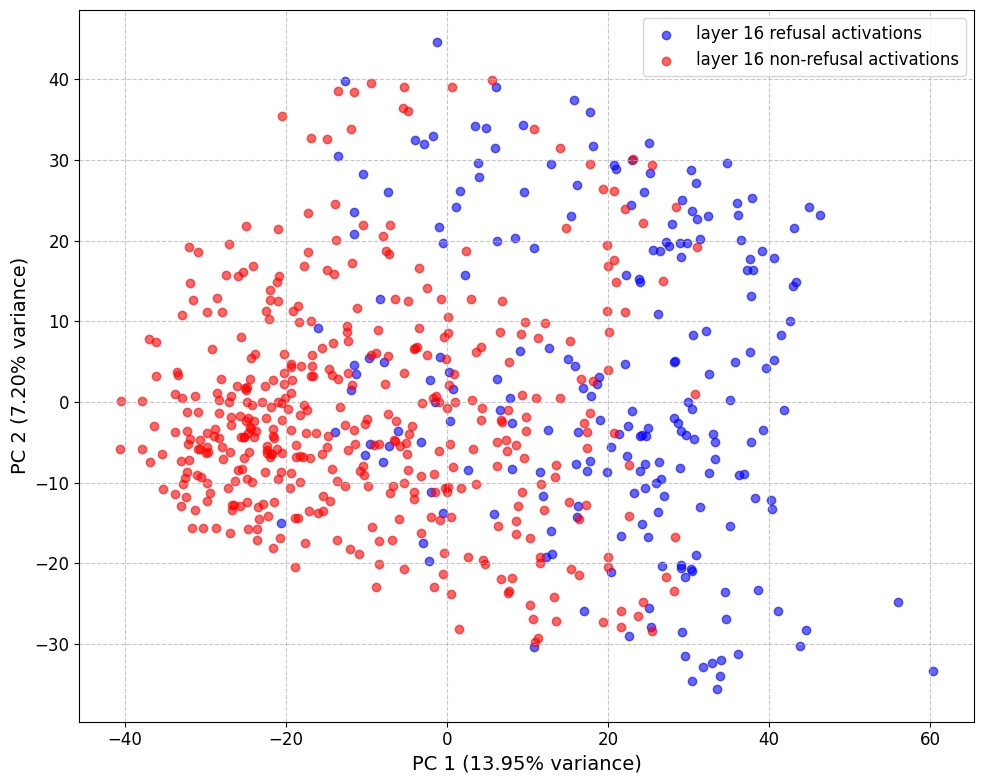


Top features for PC1:
  Feature 32: 0.0928
  Feature 3281: 0.0926
  Feature 1451: 0.0904
  Feature 2792: -0.0889
  Feature 1041: 0.0831
  Feature 1461: -0.0830
  Feature 3197: -0.0809
  Feature 662: -0.0741
  Feature 37: -0.0716
  Feature 2107: 0.0639

Top features for PC2:
  Feature 1041: 0.1095
  Feature 143: 0.1088
  Feature 458: -0.1063
  Feature 1627: -0.1044
  Feature 392: -0.0824
  Feature 2570: -0.0793
  Feature 3358: 0.0781
  Feature 516: 0.0761
  Feature 68: 0.0753
  Feature 2358: -0.0750


In [ ]:
ndims = 2
layer = 16
    
if activations_refusal is None or activations_nonrefusal is None:
    print("Failed to load one or both activation files. Exiting.")

# Check dimensions
if activations_refusal.shape != activations_nonrefusal.shape:
    print(f"Warning: Activation shapes don't match - {activations_refusal.shape} vs {activations_nonrefusal.shape}")

labels = [f"layer {layer} refusal activations", f"layer {layer} non-refusal activations"]
print("shape", activations_refusal.shape)

# Plot PCA comparison
result = plot_pca_comparison(
    activations_refusal, 
    activations_nonrefusal, 
    n_components=ndims,
    labels=labels,
    output_file=os.path.join(output_dir, f"pca_{layer}_{type}_activations.png")
)

# Analyze PCA components if requested
if result:
    analyze_pca_components(result["pca"])